# Question 12 — Illumination Correction using Homomorphic Filtering

> Optional question — requires knowledge beyond what was covered in class.

An image affected by non-uniform illumination is modelled as:
$$f(x,y) = i(x,y) \cdot r(x,y)$$
where $i(x,y)$ is the **illumination** component and $r(x,y)$ is the **reflectance** component.

## (a) Significance of the Multiplicative Model

The multiplicative model $f(x,y) = i(x,y) \cdot r(x,y)$ reflects the physical reality of how images are formed:

- **Illumination $i(x,y)$:** The amount of light falling on the scene. It varies slowly and smoothly across the image — it represents **low-frequency** spatial variation. Examples: uneven lighting from a window, shadows, spotlight effects.

- **Reflectance $r(x,y)$:** The fraction of incident light reflected by the surface at each point. It depends on the material properties of objects and varies rapidly at object boundaries — it represents **high-frequency** spatial variation. Examples: the difference between a white shirt and dark hair.

**Why multiplicative and not additive?**
In the physical world, the brightness we perceive at a point is the product of how much light hits it and how much is reflected. Doubling the illumination doubles the perceived brightness everywhere — this is a multiplicative relationship, not additive.

This model is significant because it allows us to **separate and independently process** illumination and reflectance — which is exactly what homomorphic filtering exploits.

## (b) Logarithmic Transformation to Separate Illumination and Reflectance

Taking the natural logarithm converts the multiplicative model into an **additive** one:

$$\ln f(x,y) = \ln i(x,y) + \ln r(x,y)$$

Let $z(x,y) = \ln f(x,y)$, $z_i = \ln i(x,y)$, $z_r = \ln r(x,y)$:

$$z(x,y) = z_i(x,y) + z_r(x,y)$$

Now the two components are **additively separable**:
- $z_i$ contains **low-frequency** information (slow illumination variations)
- $z_r$ contains **high-frequency** information (rapid reflectance changes at edges)

We can now apply a frequency-domain filter to suppress $z_i$ (non-uniform illumination) while enhancing $z_r$ (surface detail), then exponentiate to return to the original domain.

## (c) Homomorphic Filtering Algorithm

```
INPUT: f(x,y) — image with non-uniform illumination

STEP 1 — Log transform
    z(x,y) = ln(f(x,y) + 1)       # +1 avoids ln(0)

STEP 2 — DFT
    Z(u,v) = DFT{ z(x,y) }

STEP 3 — Frequency-domain filtering
    Design a filter H(u,v) that:
      - Attenuates low frequencies  (γ_L < 1) → reduces illumination variation
      - Boosts high frequencies     (γ_H > 1) → enhances reflectance detail
    A Gaussian-based homomorphic filter:
      H(u,v) = (γ_H - γ_L) * [1 - exp(-D²(u,v) / 2σ²)] + γ_L
    where D(u,v) = sqrt(u² + v²) is the distance from the spectrum center
    Apply: S(u,v) = H(u,v) * Z(u,v)

STEP 4 — Inverse DFT
    s(x,y) = IDFT{ S(u,v) }

STEP 5 — Exponential (inverse log)
    g(x,y) = exp(s(x,y)) - 1

OUTPUT: g(x,y) — illumination-corrected image
```

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def show_gray(img, title=''):
    plt.figure(figsize=(6, 5))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

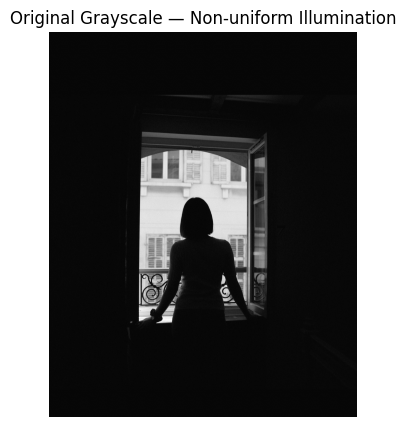

Image shape: (5867, 4693)


In [2]:
# Load image and convert to grayscale
img_bgr  = cv.imread('images/women-standing-open-door.jpg')
assert img_bgr is not None
img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
show_gray(img_gray, 'Original Grayscale — Non-uniform Illumination')
print('Image shape:', img_gray.shape)

In [3]:
# Homomorphic filter implementation
def homomorphic_filter(img, gamma_l=0.3, gamma_h=1.5, sigma=30):
    """
    Apply homomorphic filtering to a grayscale image.

    Parameters
    ----------
    img     : np.ndarray  — grayscale input image (uint8)
    gamma_l : float       — low-frequency gain  (< 1 suppresses illumination)
    gamma_h : float       — high-frequency gain (> 1 enhances reflectance)
    sigma   : float       — controls transition width between low and high freq

    Returns
    -------
    result  : np.ndarray  — filtered image (uint8)
    """
    # Step 1 — Log transform (add 1 to avoid ln(0))
    img_log = np.log1p(img.astype(np.float64))

    # Step 2 — DFT (shift zero-frequency to center)
    dft     = np.fft.fft2(img_log)
    dft_shift = np.fft.fftshift(dft)

    # Step 3 — Build Gaussian-based homomorphic filter H(u,v)
    rows, cols = img.shape
    u = np.arange(cols) - cols // 2
    v = np.arange(rows) - rows // 2
    U, V = np.meshgrid(u, v)
    D2   = U**2 + V**2                  # squared distance from center

    # H: attenuates low freq (→ gamma_l), boosts high freq (→ gamma_h)
    H = (gamma_h - gamma_l) * (1 - np.exp(-D2 / (2 * sigma**2))) + gamma_l

    # Apply filter in frequency domain
    filtered_shift = H * dft_shift

    # Step 4 — Inverse DFT
    filtered = np.fft.ifftshift(filtered_shift)
    img_back = np.real(np.fft.ifft2(filtered))

    # Step 5 — Exponential (inverse log)
    result = np.expm1(img_back)          # expm1(x) = exp(x) - 1

    # Normalize to [0, 255]
    result = np.clip(result, 0, None)
    result = (result / result.max() * 255).astype(np.uint8)

    return result, H

print('Homomorphic filter defined.')

Homomorphic filter defined.


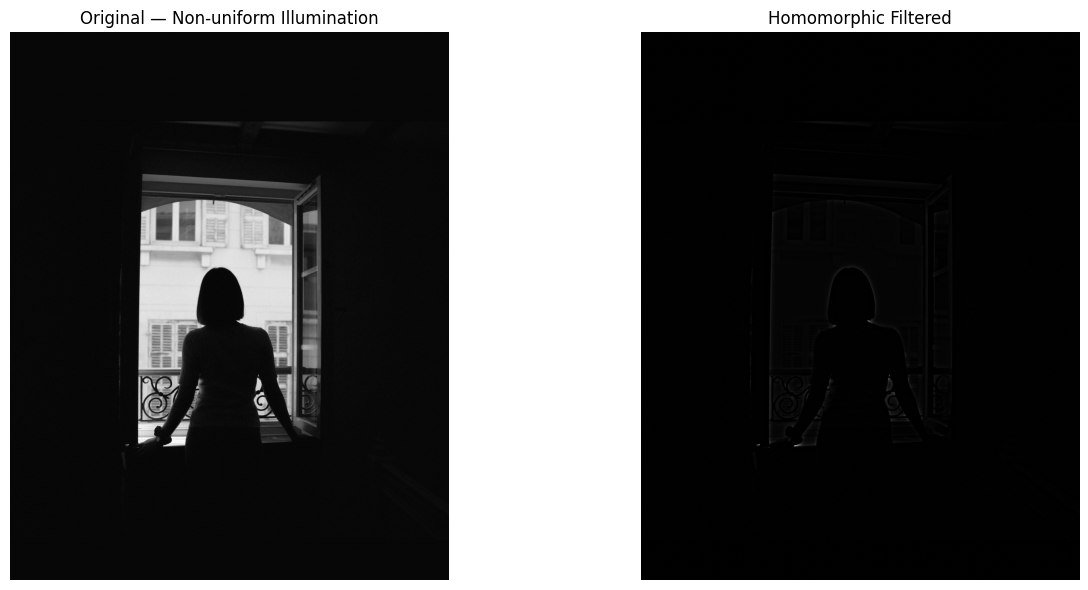

In [4]:
# Apply homomorphic filter
# gamma_l=0.3 strongly suppresses low-freq illumination
# gamma_h=1.5 boosts high-freq reflectance detail
# sigma=30    controls the transition bandwidth
result, H = homomorphic_filter(img_gray, gamma_l=0.3, gamma_h=1.5, sigma=30)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original — Non-uniform Illumination')
axes[0].axis('off')
axes[1].imshow(result, cmap='gray')
axes[1].set_title('Homomorphic Filtered')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('outputs/q12_homomorphic.png', dpi=150, bbox_inches='tight')
plt.show()

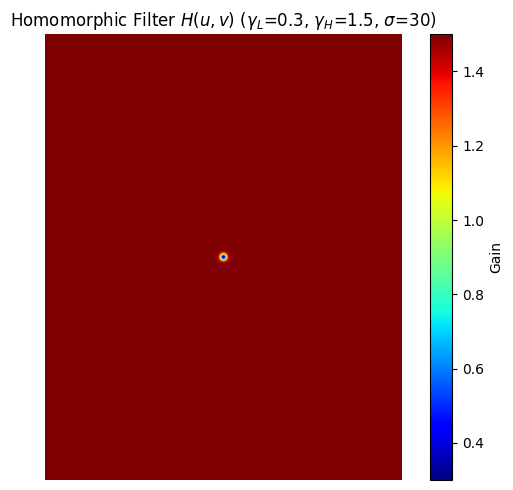

Center (low freq) gain  ≈ 0.3
Corner (high freq) gain ≈ 1.5


In [5]:
# Visualize the filter H(u,v) in frequency domain
plt.figure(figsize=(6, 5))
plt.imshow(H, cmap='jet')
plt.colorbar(label='Gain')
plt.title(rf'Homomorphic Filter $H(u,v)$ ($\gamma_L$=0.3, $\gamma_H$=1.5, $\sigma$=30)')
plt.axis('off')
plt.tight_layout()
plt.savefig('outputs/q12_filter_response.png', dpi=150, bbox_inches='tight')
plt.show()
print('Center (low freq) gain  ≈', round(H[H.shape[0]//2, H.shape[1]//2], 3))
print('Corner (high freq) gain ≈', round(H[0, 0], 3))

## (d) Homomorphic Filtering vs Histogram Equalization

| Aspect | Homomorphic Filtering | Histogram Equalization |
|---|---|---|
| **Principle** | Separates illumination and reflectance via log + frequency filtering | Redistributes pixel intensities to flatten the histogram |
| **Domain** | Frequency domain (DFT-based) | Spatial domain (intensity mapping) |
| **Illumination** | Directly targets and suppresses non-uniform illumination | Does not explicitly model illumination — treats all pixels equally |
| **Edge preservation** | Preserves edges by boosting high frequencies | Can over-enhance noise and low-contrast regions |
| **Control** | Fine-grained via $\gamma_L$, $\gamma_H$, $\sigma$ | Limited control — only one parameter (number of bins) |
| **Artifacts** | Can introduce ringing if $\sigma$ is too small | Can wash out fine detail; may amplify noise |
| **Complexity** | Higher — requires DFT | Lower — simple CDF mapping |

**When to prefer homomorphic filtering:**
- The image has **spatially varying illumination** (e.g., one side lit, other in shadow)
- You want to **preserve or enhance local contrast** while correcting global lighting
- The illumination variation is a known physical effect (e.g., indoor/outdoor scene)
- Examples: face recognition under uneven lighting, document scanning with shadows, medical imaging

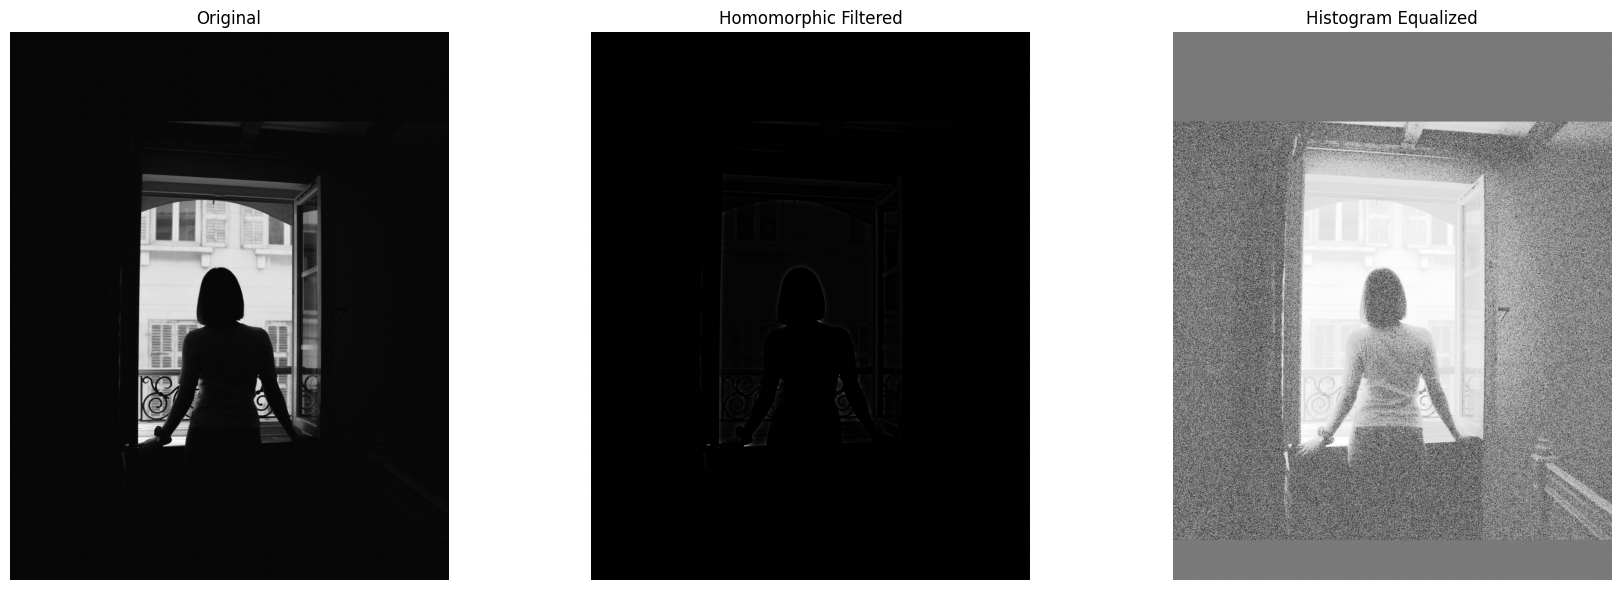

Observations:

  Illumination correction:
    Homomorphic: dark room interior is lifted while bright window is
    toned down — the illumination gap is reduced significantly.
    Histogram eq: also brightens dark regions but less selectively.

  Contrast enhancement:
    Homomorphic: local contrast (clothing, door frame) is enhanced
    by the gamma_h boost on high frequencies.
    Histogram eq: global contrast improved but fine details can be lost.

  Artifacts:
    Homomorphic: slight halo around the window frame (ringing) due to
    the sharp transition between dark and bright regions.
    Histogram eq: bright exterior may appear over-saturated/washed out.


In [6]:
# (e) Compare homomorphic filtering vs histogram equalization
hist_eq = cv.equalizeHist(img_gray)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, im, t in zip(axes,
    [img_gray, result, hist_eq],
    ['Original', 'Homomorphic Filtered', 'Histogram Equalized']):
    ax.imshow(im, cmap='gray')
    ax.set_title(t)
    ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/q12_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observations:')
print()
print('  Illumination correction:')
print('    Homomorphic: dark room interior is lifted while bright window is')
print('    toned down — the illumination gap is reduced significantly.')
print('    Histogram eq: also brightens dark regions but less selectively.')
print()
print('  Contrast enhancement:')
print('    Homomorphic: local contrast (clothing, door frame) is enhanced')
print('    by the gamma_h boost on high frequencies.')
print('    Histogram eq: global contrast improved but fine details can be lost.')
print()
print('  Artifacts:')
print('    Homomorphic: slight halo around the window frame (ringing) due to')
print('    the sharp transition between dark and bright regions.')
print('    Histogram eq: bright exterior may appear over-saturated/washed out.')